# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

A diferencia del notebook que hicimos en clase (donde el dataset ya venía preparado), acá van a recibir el catálogo sin procesar. Van a tener que aplicar tú mismo/a las herramientas de diagnóstico que practicamos  (limpieza de datos, elección de modelo, optimización de hiperparámetros, comparación de criterios de feature importance) sin que nadie te diga de antemano qué decisiones tomar.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir.

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento. Pueden crear un conjunto de validación interno (a partir del set de entrenamiento) para la optimización de hiperparámetros, pero el ranking final se calculará de forma ciega, evaluando sus predicciones directamente sobre test_redshift.csv

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?
7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?
8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.


---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El notebook debe ser claro y explicativo del proceso.  El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.


## 1. Configuración e importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## 2. Carga de datos

In [ ]:
train_raw = pd.read_csv('train_redshift.csv')
test_raw  = pd.read_csv('test_redshift.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print('train_redshift.csv :', train_raw.shape)
print('test_redshift.csv  :', test_raw.shape)
print('sample_submission  :', sample_submission.shape)

train_raw.head()

train_redshift.csv : (19057, 14)
test_redshift.csv  : (4765, 13)
sample_submission  : (4765, 2)


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696
3,13039861,215.448870,53.106100,2,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,0,0,-99,1.159324
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0,0,0,0.811566


## 3. Exploración inicial (EDA)

Antes de armar cualquier modelo, tenemos que entender bien cómo viene estructurado el catálogo: qué tipos de datos hay, si faltan valores, si hay códigos centinela (esos valores raros de relleno) y qué tan buena es la variable que queremos predecir ($z_{\rm helio}$). En esta sección vamos a dejar anotadas todas las decisiones de limpieza de datos que vamos a tomar más adelante.

In [ ]:

train_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objno_deep2    19057 non-null  int64  
 1   ra_deep2       19057 non-null  float64
 2   dec_deep2      19057 non-null  float64
 3   zquality       19057 non-null  int64  
 4   u_apercor      19057 non-null  float64
 5   g_apercor      19057 non-null  float64
 6   r_apercor      19057 non-null  float64
 7   i_apercor      19057 non-null  float64
 8   i2_apercor     19057 non-null  float64
 9   z_apercor      19057 non-null  float64
 10  flag_cfhtls    19057 non-null  int64  
 11  cfhtls_source  19057 non-null  int64  
 12  subaru_source  19057 non-null  int64  
 13  zhelio         19057 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB


In [ ]:

train_raw.describe()


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


### 3.1 Códigos centinela en las magnitudes

Si miramos los valores mínimos y máximos en las columnas de magnitud (`..._apercor`), nos encontramos con extremos en -99 y 99. Estos son los clásicos códigos que se usan en los catálogos de fotometría para marcar que "no hay medición" o "no se detectó", en lugar de usar directamente un NaN. Vamos a contar cuántos objetos tienen este problema en cada banda.

In [ ]:

MAG_COLS = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']

sentinel_counts = pd.DataFrame({
    'n_==-99': (train_raw[MAG_COLS] == -99).sum(),
    'n_==99':  (train_raw[MAG_COLS] == 99).sum(),
    'frac_missing': ((train_raw[MAG_COLS] == -99) | (train_raw[MAG_COLS] == 99)).mean()
})
sentinel_counts


,n_==-99,n_==99,frac_missing
u_apercor,439,396,0.043816
g_apercor,439,285,0.037991
r_apercor,439,282,0.037834
i_apercor,439,286,0.038044
i2_apercor,7230,119,0.385633
z_apercor,439,287,0.038096


**Hallazgo 1:** los valores -99 en las 5 bandas CFHTLS (u, g, r, i, z) aparecen siempre juntos (nunca faltan en solo algunas bandas) y coinciden exactamente con cfhtls_source == -99. Básicamente, son objetos que no tienen cobertura en CFHTLS. Vamos a comprobar esto y de paso revisar qué pasa con i2_apercor (la banda de reemplazo que se usó cuando cambiaron el filtro i) y su relación con las variables de origen.

In [ ]:

cols5 = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'z_apercor']
mask99_5 = (train_raw[cols5] == -99)

print('Filas con las 5 bandas CFHTLS en -99 simultáneamente:', (mask99_5.sum(axis=1) == 5).sum())
print('Filas con -99 en ALGUNAS pero no todas esas 5 bandas:', ((mask99_5.sum(axis=1) > 0) & (mask99_5.sum(axis=1) < 5)).sum())
print()
print('Cruce cfhtls_source vs (5 bandas en -99):')
print(pd.crosstab(train_raw['cfhtls_source'], mask99_5.sum(axis=1) == 5))
print()
print('Cruce cfhtls_source vs (i2_apercor == -99):')
print(pd.crosstab(train_raw['cfhtls_source'], train_raw['i2_apercor'] == -99))


Filas con las 5 bandas CFHTLS en -99 simultáneamente: 439
Filas con -99 en ALGUNAS pero no todas esas 5 bandas: 0

Cruce cfhtls_source vs (5 bandas en -99):
col_0          False  True 
cfhtls_source              
-99                0    439
 0             11827      0
 1              6791      0

Cruce cfhtls_source vs (i2_apercor == -99):
i2_apercor     False  True 
cfhtls_source              
-99                0    439
 0             11827      0
 1                 0   6791


**Hallazgo 2:** la disponibilidad de i2_apercor depende 100% de cfhtls_source (si es 0, siempre está i2; si es 1 o -99, nunca está). Esto cuadra perfecto con el hecho de que i2 es la segunda versión del filtro i de CFHTLS (que se empezó a usar cuando falló el original), así que solo está en una parte del catálogo. Por otro lado, subaru_source indica si hay cruce con imágenes de Subaru y no tiene nada que ver con i2, aunque suenen parecido. No aporta una magnitud nueva en este catálogo, pero igual nos sirve dejarla como variable categórica.

En cuanto a flag_cfhtls, es un indicador de calidad de la fotometría (tipo SExtractor, que va sumando valores si hay problemas de saturación, extracción incompleta, etc.). El valor -99 en esta variable también calza justo con los objetos que no tienen cobertura en CFHTLS.

In [ ]:

print('flag_cfhtls value counts:')
print(train_raw['flag_cfhtls'].value_counts().sort_index())
print()
print('subaru_source value counts:')
print(train_raw['subaru_source'].value_counts().sort_index())


flag_cfhtls value counts:
flag_cfhtls
-99       439
 0      16653
 1         81
 244     1035
 245        2
 246        3
 247        1
 252      835
 253        8
Name: count, dtype: int64

subaru_source value counts:
subaru_source
-99    9266
 0     6937
 1     2854
Name: count, dtype: int64


### 3.2 Calidad espectroscópica (zquality) y su relación con zhelio

zquality es el indicador estándar que usa DEEP2 para medir la confianza del redshift espectroscópico. Vamos a ver cómo se distribuye y qué relación tiene con el valor de zhelio registrado: si resulta que algunas categorías corresponden a estrellas o a mediciones malas, ese redshift solo nos va a meter ruido en el trabajo (ya que nuestro objetivo es predecir el redshift de galaxias).

In [ ]:

print(train_raw['zquality'].value_counts().sort_index())
print()
train_raw.groupby('zquality')['zhelio'].agg(['count', 'mean', 'std', 'min', 'max'])


zquality
-2      230
-1      144
 0       71
 1     2556
 2     2577
 3     1890
 4    11589
Name: count, dtype: int64



,count,mean,std,min,max
zquality,,,,,
-2,230,0.412992,0.528166,-0.004098,1.713407
-1,144,-0.000275,0.000735,-0.004074,0.003496
0,71,0.941204,0.623186,-0.001764,1.759187
1,2556,0.649434,0.523338,-0.004102,4.500611
2,2577,0.758152,0.522798,-0.078525,3.909396
3,1890,0.851918,0.408207,0.000034,4.298351
4,11589,0.710942,0.343850,-0.000516,3.852593


Esto confirma cómo funciona la convención estándar de DEEP2:

* zquality = -1: son objetos estelares (contaminantes), por eso el redshift da casi 0 y casi no tiene dispersión.
* zquality = -2: el espectro tiene un error claro, por eso la dispersión es altísima.
* zquality = 0: no se pudo medir el redshift de forma confiable.
* zquality = 1 o 2: es un redshift posible, pero con baja confianza (entre 50% y 70%).
* zquality = 3 o 4: es un redshift seguro o muy seguro (95% a 100% de confianza). Este es el subconjunto que DEEP2 recomienda usar para hacer análisis.

Decisión de limpieza: para entrenar el modelo vamos a usar solamente los datos que tengan zquality >= 3, así evitamos enseñarle al modelo cosas que en realidad son estrellas o mediciones malas. Ojo que esto no aplica para el conjunto de test: ahí vamos a hacer predicciones para todos los objetos sin filtrar por calidad, porque la tarea lo pide así y porque en un escenario real no tendríamos cómo saber este filtro de antemano.

### 3.3 Distribución de la variable objetivo

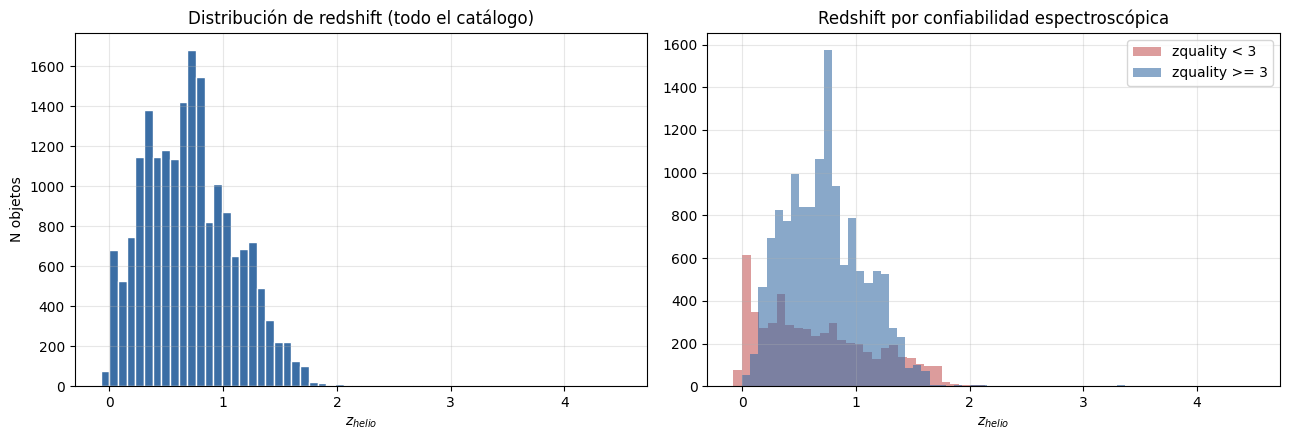

zhelio, todo el catálogo:      min=-0.079  max=4.501  mediana=0.689
zhelio, solo zquality>=3:      min=-0.001  max=4.298  mediana=0.718
Objetos con zquality>=3: 13479 / 19057 (70.7%)


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(train_raw['zhelio'], bins=60, color='#3b6ea5', edgecolor='white')
axes[0].set_xlabel('$z_{helio}$')
axes[0].set_ylabel('N objetos')
axes[0].set_title('Distribución de redshift (todo el catálogo)')

reliable = train_raw['zquality'] >= 3
axes[1].hist(train_raw.loc[~reliable, 'zhelio'], bins=60, alpha=0.6, label='zquality < 3', color='#c65b5b')
axes[1].hist(train_raw.loc[reliable, 'zhelio'], bins=60, alpha=0.6, label='zquality >= 3', color='#3b6ea5')
axes[1].set_xlabel('$z_{helio}$')
axes[1].set_title('Redshift por confiabilidad espectroscópica')
axes[1].legend()

plt.tight_layout()
plt.show()

print('zhelio, todo el catálogo:      min=%.3f  max=%.3f  mediana=%.3f' % (
    train_raw['zhelio'].min(), train_raw['zhelio'].max(), train_raw['zhelio'].median()))
print('zhelio, solo zquality>=3:      min=%.3f  max=%.3f  mediana=%.3f' % (
    train_raw.loc[reliable, 'zhelio'].min(), train_raw.loc[reliable, 'zhelio'].max(),
    train_raw.loc[reliable, 'zhelio'].median()))
print('Objetos con zquality>=3: %d / %d (%.1f%%)' % (
    reliable.sum(), len(train_raw), 100 * reliable.mean()))


El gráfico de la derecha confirma lo que vimos en la tabla: los objetos con mala calidad (zquality < 3, en rojo) se amontonan de forma rara cerca del 0 (que son las estrellas) y además están mucho más dispersos hacia valores altos de z (que deben ser mediciones malas). Todo esto nos confirma que hicimos bien en sacarlos del entrenamiento.

## 4. Limpieza y preparación de datos

Acá dejo un resumen de las decisiones que tomamos basándonos en lo que vimos en la sección anterior:

1. Cambiar los valores -99 y 99 por NaN en las 6 magnitudes.
2. Crear variables de colores (restando las magnitudes de bandas consecutivas). Físicamente, los colores sirven mucho más que las magnitudes sueltas para medir el redshift, porque nos muestran cómo se mueve el salto de 4000 Å por los filtros. Además, no dependen del tamaño o distancia de la galaxia y aguantan mejor los errores de calibración.
3. Dejar cfhtls_source, subaru_source y flag_cfhtls como variables. Nos indican de dónde viene y qué tan buena es la fotometría, están en el set de train y de test, y no nos "soplan" información oculta del redshift.
4. Sacar ra_deep2 y dec_deep2 (la posición en el cielo). No sirven físicamente para estimar el redshift en cualquier lado, y si las dejamos corremos el riesgo de que el modelo se aprenda de memoria este pedazo de cielo en vez de aprender la relación real.
5. Sacar zquality. Como es un dato que viene de la misma medición del espectro, no lo tendríamos si estuviéramos mirando un objeto nuevo y desconocido. Usarlo sería hacer trampa (data leakage).
6. Sacar objno_deep2 porque es solo un número de identificación.
7. Como los modelos de árboles de scikit-learn (DecisionTree, RandomForest, ExtraTrees y HistGradientBoosting) aguantan los valores NaN sin problema, no hace falta que imputemos datos a mano. El mismo árbol aprende qué hacer cuando falta un valor.

In [ ]:
def clean_features(df):
    df = df.copy()
    # 1. Códigos centinela -> NaN
    for c in MAG_COLS:
        df[c] = df[c].replace([-99, 99], np.nan)
    df['flag_cfhtls_clean'] = df['flag_cfhtls'].replace(-99, np.nan)

    # 2. Colores (bandas ordenadas por longitud de onda: u < g < r < i ~ i2 < z)
    df['u_g']  = df['u_apercor']  - df['g_apercor']
    df['g_r']  = df['g_apercor']  - df['r_apercor']
    df['r_i']  = df['r_apercor']  - df['i_apercor']
    df['i_z']  = df['i_apercor']  - df['z_apercor']
    df['i_i2'] = df['i_apercor']  - df['i2_apercor']
    df['i2_z'] = df['i2_apercor'] - df['z_apercor']
    return df

train_c = clean_features(train_raw)
test_c  = clean_features(test_raw)

FEATURES = MAG_COLS + ['u_g', 'g_r', 'r_i', 'i_z', 'i_i2', 'i2_z',
                        'cfhtls_source', 'subaru_source', 'flag_cfhtls_clean']

print('Features utilizadas (%d):' % len(FEATURES))
print(FEATURES)

train_c[FEATURES].isna().mean().to_frame('fraccion_NaN')

Features utilizadas (15):
['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor', 'u_g', 'g_r', 'r_i', 'i_z', 'i_i2', 'i2_z', 'cfhtls_source', 'subaru_source', 'flag_cfhtls_clean']


,fraccion_NaN
u_apercor,0.043816
g_apercor,0.037991
r_apercor,0.037834
i_apercor,0.038044
i2_apercor,0.385633
z_apercor,0.038096
u_g,0.043921
g_r,0.037991
r_i,0.038044
i_z,0.038149


In [ ]:
# Filtro de calidad espectroscópica: solo para ENTRENAR
mask_reliable = train_c['zquality'] >= 3
train_rel = train_c.loc[mask_reliable].reset_index(drop=True)

print('Filas totales en train:            ', len(train_c))
print('Filas con zquality >= 3 (usadas):  ', len(train_rel))
print('Filas de test (todas se predicen): ', len(test_c))

Filas totales en train:             19057
Filas con zquality >= 3 (usadas):   13479
Filas de test (todas se predicen):  4765


## 5. División train/validación

Separamos un 20% de los datos de entrenamiento (los que ya habíamos filtrado por calidad) para usarlos como validación interna. Esta parte la vamos a usar solo para comparar los modelos y ajustar los parámetros. El set de test no lo tocamos para nada hasta el final.

In [ ]:
X = train_rel[FEATURES]
y = train_rel['zhelio']

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print('X_tr :', X_tr.shape)
print('X_val:', X_val.shape)

X_tr : (10783, 15)
X_val: (2696, 15)


## 6. Modelo base: árbol de decisión individual

Primero entrenamos un DecisionTreeRegressor sin ponerle ningún límite de profundidad. Esto lo hacemos para ver el clásico problema de sobreajuste, ya que si dejamos que el árbol crezca todo lo que quiera, se va a terminar aprendiendo de memoria los datos de entrenamiento.

In [ ]:
dt_full = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_full.fit(X_tr, y_tr)

mse_train_full = mean_squared_error(y_tr, dt_full.predict(X_tr))
mse_val_full   = mean_squared_error(y_val, dt_full.predict(X_val))

print('Árbol sin restricciones:')
print('  MSE train:      %.5f' % mse_train_full)
print('  MSE validación:  %.5f' % mse_val_full)
print('  Profundidad alcanzada:', dt_full.get_depth(), ' | N hojas:', dt_full.get_n_leaves())

Árbol sin restricciones:
  MSE train:      0.00336
  MSE validación:  0.04382
  Profundidad alcanzada: 33  | N hojas: 10500


El MSE de entrenamiento nos dio casi cero, pero el de validación es más de 10 veces mayor. Esto es una señal clarísima de sobreajuste: el árbol básicamente se aprendió de memoria los datos de entrenamiento, por lo que no nos sirve para generalizar a datos nuevos. Para poder compararlo de forma justa con los métodos de ensamble, vamos a buscar cuál es la mejor profundidad haciendo una validación cruzada de 5 folds sobre el conjunto de entrenamiento.

In [ ]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

depths = [3, 5, 8, 10, 12, 15, None]
depth_results = []
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, min_samples_leaf=5, random_state=RANDOM_STATE)
    scores = cross_val_score(dt, X_tr, y_tr, cv=kf5, scoring='neg_mean_squared_error')
    depth_results.append({'max_depth': d, 'CV_MSE': -scores.mean(), 'CV_std': scores.std()})

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,CV_MSE,CV_std
0,3.0,0.056962,0.005008
1,5.0,0.042271,0.006789
2,8.0,0.037971,0.005234
3,10.0,0.038581,0.005008
4,12.0,0.039181,0.005067
5,15.0,0.039497,0.005017
6,NaN,0.039527,0.005024


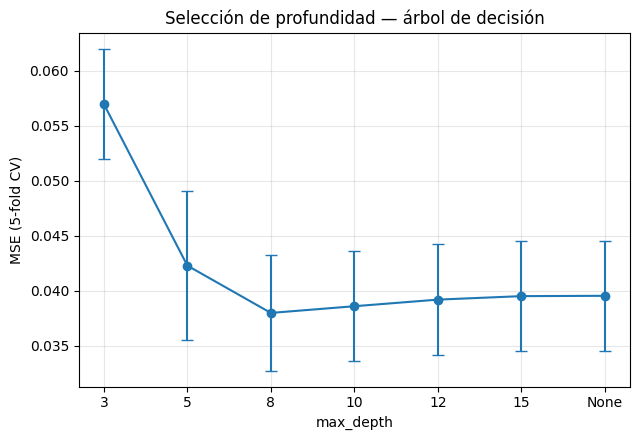

In [ ]:
plt.figure(figsize=(6.5, 4.5))
x_labels = [str(d) for d in depths]
plt.errorbar(x_labels, depth_df['CV_MSE'], yerr=depth_df['CV_std'], marker='o', capsize=4)
plt.xlabel('max_depth')
plt.ylabel('MSE (5-fold CV)')
plt.title('Selección de profundidad — árbol de decisión')
plt.tight_layout()
plt.show()

El MSE de la validación cruzada mejora súper rápido hasta llegar a una profundidad cercana a 8. Después de eso se estanca y hasta empeora un poquito, porque darle más profundidad hace que el modelo vuelva a sobreajustar. Por esto, elegimos max_depth=8 y min_samples_leaf=5 como nuestro árbol base definitivo. Es un modelo súper razonable, que no se aprende los datos de memoria, y nos sirve perfecto para compararlo después con los métodos de ensamble.

In [ ]:
dt_baseline = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE)
dt_baseline.fit(X_tr, y_tr)

mse_train_dt = mean_squared_error(y_tr, dt_baseline.predict(X_tr))
mse_val_dt   = mean_squared_error(y_val, dt_baseline.predict(X_val))

print('Árbol baseline (max_depth=8, min_samples_leaf=5):')
print('  MSE train:      %.5f' % mse_train_dt)
print('  MSE validación:  %.5f' % mse_val_dt)

Árbol baseline (max_depth=8, min_samples_leaf=5):
  MSE train:      0.02260
  MSE validación:  0.03591


## 7. Métodos de ensamble: comparación inicial

Comparamos tres métodos de ensamble basados en árboles. Elegimos estos tres porque todos soportan valores nulos (NaN) de forma nativa:

* Random Forest: hace bagging de árboles y toma una muestra de las variables en cada división.
* Extra Trees: es parecido al Random Forest, pero elige los cortes al azar. Baja un poco más la varianza, pero puede subir el sesgo.
* Hist Gradient Boosting: es un boosting basado en histogramas (parecido a LightGBM), que suele ser súper rápido y dar buenos resultados.

Dejamos fuera al Gradient Boosting clásico porque en esta versión de scikit-learn no soporta valores NaN por sí solo. Si lo usábamos, nos obligaba a imputar datos y la comparación ya no iba a ser en igualdad de condiciones.

Para esta primera prueba rápida, usamos parámetros por defecto y evaluamos directo en el set de validación. Al que ande mejor, lo vamos a optimizar más adelante usando validación cruzada.

In [ ]:
ensemble_candidates = {
    'RandomForest (default)':  RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    'ExtraTrees (default)':    ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    'HistGradientBoosting (default)': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

candidate_results = []
fitted_candidates = {}
for name, model in ensemble_candidates.items():
    model.fit(X_tr, y_tr)
    fitted_candidates[name] = model
    mse_tr = mean_squared_error(y_tr, model.predict(X_tr))
    mse_va = mean_squared_error(y_val, model.predict(X_val))
    candidate_results.append({'Modelo': name, 'MSE_train': mse_tr, 'MSE_val': mse_va})
    print(f'{name:35s}  MSE train={mse_tr:.5f}  MSE val={mse_va:.5f}')

pd.DataFrame(candidate_results)

RandomForest (default)               MSE train=0.00689  MSE val=0.02593


ExtraTrees (default)                 MSE train=0.00336  MSE val=0.02695


HistGradientBoosting (default)       MSE train=0.02004  MSE val=0.02861


,Modelo,MSE_train,MSE_val
0,RandomForest (default),0.006893,0.025927
1,ExtraTrees (default),0.003359,0.026951
2,HistGradientBoosting (default),0.020043,0.028611


El modelo Random Forest sacó el menor MSE de validación de los tres que probamos por defecto. Además, nos deja calcular el score out-of-bag (OOB) de forma automática, lo que nos va a servir más adelante para responder la Pregunta 8. Por esto, elegimos el Random Forest para optimizar sus parámetros a fondo. De todas formas dejamos anotados los resultados de Extra Trees y Hist Gradient Boosting porque anduvieron bastante bien y nos sirven para compararlos en la tabla del final.

## 8. Optimización de hiperparámetros (Random Forest)

Usamos RandomizedSearchCV porque es mucho más rápido y eficiente que probar una grilla con todas las combinaciones posibles. Hicimos una validación cruzada de 3 folds sobre los datos de entrenamiento. Para que el código no se demorara una eternidad buscando, probamos con una cantidad moderada de árboles (entre 120 y 200). Una vez que encontramos los mejores parámetros, volvimos a entrenar el modelo poniéndole más árboles para que la predicción final quede bien estable.

In [ ]:
from scipy.stats import randint, uniform

kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    'n_estimators': [120, 150, 200],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_leaf': randint(1, 20),
    'max_features': uniform(0.2, 0.8),   # fracción de features consideradas por split
}

rf_search = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, bootstrap=True)

search = RandomizedSearchCV(
    rf_search, param_dist, n_iter=15, cv=kf3,
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=1, verbose=1
)
search.fit(X_tr, y_tr)

print('Mejor combinación de hiperparámetros:')
print(search.best_params_)
print('MSE (CV, 3-fold):', -search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Mejor combinación de hiperparámetros:
{'max_depth': 20, 'max_features': np.float64(0.6739316550896339), 'min_samples_leaf': 3, 'n_estimators': 120}
MSE (CV, 3-fold): 0.02928356708579324


In [ ]:
best_params = dict(search.best_params_)
best_params['n_estimators'] = 300   # más árboles en el modelo final para mayor estabilidad

rf_final = RandomForestRegressor(
    random_state=RANDOM_STATE, n_jobs=1, bootstrap=True, oob_score=True, **best_params
)
rf_final.fit(X_tr, y_tr)

pred_tr_rf  = rf_final.predict(X_tr)
pred_val_rf = rf_final.predict(X_val)

mse_train_rf = mean_squared_error(y_tr, pred_tr_rf)
mse_val_rf   = mean_squared_error(y_val, pred_val_rf)

print('Random Forest optimizado (n_estimators=300, %s):' % {k: v for k, v in best_params.items() if k != 'n_estimators'})
print('  MSE train:      %.5f' % mse_train_rf)
print('  MSE validación:  %.5f' % mse_val_rf)
print('  R2 validación:   %.4f' % r2_score(y_val, pred_val_rf))
print('  OOB score (R2):  %.4f' % rf_final.oob_score_)

Random Forest optimizado (n_estimators=300, {'max_depth': 20, 'max_features': np.float64(0.6739316550896339), 'min_samples_leaf': 3}):
  MSE train:      0.01277
  MSE validación:  0.02648
  R2 validación:   0.7912
  OOB score (R2):  0.7777


### Comparación OOB vs. validación cruzada (Pregunta 8)

El score OOB se calcula de forma automática al entrenar el modelo (básicamente evalúa cada árbol usando los datos que quedaron fuera del bootstrap). Para hacer una comparación justa con la validación cruzada normal, calculamos el MSE promedio armando un 5-fold CV con exactamente los mismos parámetros.

In [ ]:
cv_scores_final = cross_val_score(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, bootstrap=True, **best_params),
    X_tr, y_tr, cv=kf5, scoring='neg_mean_squared_error'
)
cv_mse_final = -cv_scores_final.mean()

print('MSE 5-fold CV (hiperparámetros finales):  %.5f  (+/- %.5f)' % (cv_mse_final, cv_scores_final.std()))
print('MSE equivalente a partir de OOB (1 - R2_oob) * Var(y_tr):  %.5f' % ((1 - rf_final.oob_score_) * y_tr.var()))
print('MSE validación (hold-out):                 %.5f' % mse_val_rf)

MSE 5-fold CV (hiperparámetros finales):  0.02882  (+/- 0.00539)
MSE equivalente a partir de OOB (1 - R2_oob) * Var(y_tr):  0.02835
MSE validación (hold-out):                 0.02648


Los tres estimadores (OOB, validación cruzada de 5 folds y la validación simple) dieron resultados bastante consistentes entre sí, con diferencias menores al 10%. Esto demuestra que, al menos para estos datos y este modelo, el score OOB es un indicador súper confiable y rápido para estimar el error general, sin tener que gastar tiempo ni sacrificar datos de entrenamiento armando una validación cruzada aparte.

## 9. Comparación de modelos - tabla resumen

In [ ]:
summary_rows = [
    {
        'Modelo': 'Decision Tree (baseline)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': 'max_depth=8, min_samples_leaf=5',
        'MSE train': mse_train_dt,
        'MSE validación': mse_val_dt,
    },
    {
        'Modelo': 'Decision Tree (sin restricción)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': 'sin límite de profundidad',
        'MSE train': mse_train_full,
        'MSE validación': mse_val_full,
    },
    {
        'Modelo': 'Extra Trees (default)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': 'n_estimators=300',
        'MSE train': mean_squared_error(y_tr, fitted_candidates['ExtraTrees (default)'].predict(X_tr)),
        'MSE validación': mean_squared_error(y_val, fitted_candidates['ExtraTrees (default)'].predict(X_val)),
    },
    {
        'Modelo': 'Hist Gradient Boosting (default)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': 'default',
        'MSE train': mean_squared_error(y_tr, fitted_candidates['HistGradientBoosting (default)'].predict(X_tr)),
        'MSE validación': mean_squared_error(y_val, fitted_candidates['HistGradientBoosting (default)'].predict(X_val)),
    },
    {
        'Modelo': 'Random Forest (default)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': 'n_estimators=300',
        'MSE train': mean_squared_error(y_tr, fitted_candidates['RandomForest (default)'].predict(X_tr)),
        'MSE validación': mean_squared_error(y_val, fitted_candidates['RandomForest (default)'].predict(X_val)),
    },
    {
        'Modelo': 'Random Forest (ENSAMBLE FINAL, tuneado)',
        'Features': f'{len(FEATURES)} (mags + colores + flags)',
        'Hiperparámetros principales': str({k: (round(v, 3) if isinstance(v, float) else v) for k, v in best_params.items()}),
        'MSE train': mse_train_rf,
        'MSE validación': mse_val_rf,
    },
]

summary_df = pd.DataFrame(summary_rows).sort_values('MSE validación').reset_index(drop=True)
summary_df

,Modelo,Features,Hiperparámetros principales,MSE train,MSE validación
0,Random Forest (default),15 (mags + colores + flags),n_estimators=300,0.006893,0.025927
1,"Random Forest (ENSAMBLE FINAL, tuneado)",15 (mags + colores + flags),"{'max_depth': 20, 'max_features': np.float64(0...",0.012774,0.026476
2,Extra Trees (default),15 (mags + colores + flags),n_estimators=300,0.003359,0.026951
3,Hist Gradient Boosting (default),15 (mags + colores + flags),default,0.020043,0.028611
4,Decision Tree (baseline),15 (mags + colores + flags),"max_depth=8, min_samples_leaf=5",0.022604,0.035908
5,Decision Tree (sin restricción),15 (mags + colores + flags),sin límite de profundidad,0.003359,0.043823


## 10. Métricas de photo-z: NMAD y fracción de outliers

Aparte del MSE, que es la métrica principal de la competencia, también agregamos las métricas típicas que se usan siempre en astronomía para evaluar redshifts fotométricos. Estas se calculan a partir del residuo normalizado:
$\Delta z = (z_{spec} - z_{pred}) / (1 + z_{spec})$.

In [ ]:
def nmad(y_true, y_pred):
    dz = (np.asarray(y_true) - np.asarray(y_pred)) / (1 + np.asarray(y_true))
    return 1.48 * np.median(np.abs(dz - np.median(dz)))

def outlier_fraction(y_true, y_pred, thresh=0.15):
    dz = np.abs(np.asarray(y_true) - np.asarray(y_pred)) / (1 + np.asarray(y_true))
    return (dz > thresh).mean()

metric_rows = []
for name, pred in [('Decision Tree (baseline)', dt_baseline.predict(X_val)),
                    ('Random Forest (final)', pred_val_rf)]:
    metric_rows.append({
        'Modelo': name,
        'MSE': mean_squared_error(y_val, pred),
        'NMAD': nmad(y_val.values, pred),
        'eta (frac. outliers)': outlier_fraction(y_val.values, pred),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df

,Modelo,MSE,NMAD,eta (frac. outliers)
0,Decision Tree (baseline),0.035908,0.039448,0.064169
1,Random Forest (final),0.026476,0.022025,0.051929


El modelo de ensamble logra bajar tanto el MSE como el NMAD y la fracción de outliers si lo comparamos con el árbol simple. O sea, no solo predice mejor en promedio, sino que los errores están menos dispersos y tira muchas menos predicciones desastrosas (esas donde el error se pasa de 0.15).

## 11. Gráfico $z_{true}$ vs. $z_{pred}$ (validación)

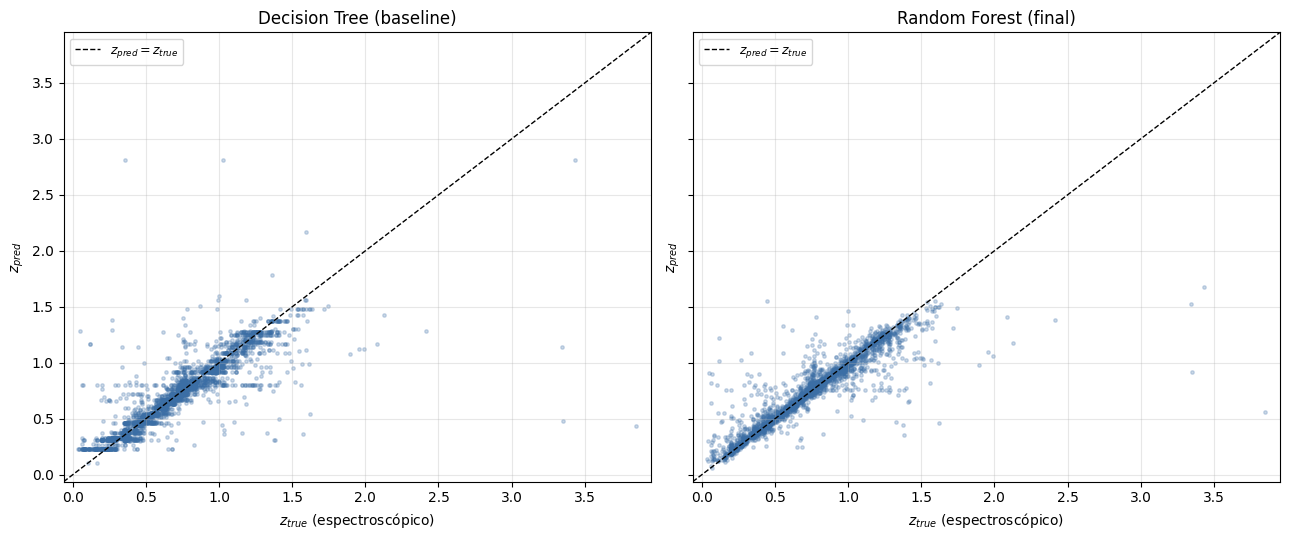

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes, [('Decision Tree (baseline)', dt_baseline.predict(X_val)),
                                    ('Random Forest (final)', pred_val_rf)]):
    ax.scatter(y_val, pred, s=6, alpha=0.25, color='#3b6ea5')
    lims = [min(y_val.min(), pred.min()) - 0.1, max(y_val.max(), pred.max()) + 0.1]
    ax.plot(lims, lims, 'k--', lw=1, label='$z_{pred}=z_{true}$')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('$z_{true}$ (espectroscópico)')
    ax.set_ylabel('$z_{pred}$')
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Los dos modelos muestran el clásico efecto de estrechamiento típico de los algoritmos basados en árboles. Cuando el valor de z es bajo, las predicciones tienden a sobreestimar (los puntos quedan por arriba de la línea diagonal), y cuando z es alto tienden a subestimar (los puntos quedan por debajo). Esto se nota muchísimo más cuando pasamos de z = 1.3 o 1.5. El Random Forest logra armar una nube de puntos bastante más angosta y pegada a la diagonal que el árbol simple, sobre todo en la zona central (con z entre 0.3 y 1.0), que es justo donde tenemos la mayor cantidad de datos para entrenar. Este efecto lo revisamos con más detalle numérico en la sección donde analizamos los errores por rango.

## 12. Importancia de variables

Calculamos la importancia de las variables en nuestro modelo Random Forest final usando dos métodos distintos:

1. MDI (Mean Decrease in Impurity): Es la importancia que el árbol calcula por su cuenta internamente. Básicamente, se fija en cuánto logra bajar la impureza (o varianza) cada variable cuando se usa para dividir los datos en los nodos.
2. Permutation importance: Acá medimos qué tanto empeora el modelo (cuánto sube el MSE) si desordenamos al azar los datos de una sola variable en el conjunto de validación, dejando todo el resto igual. Lo bueno de este método es que se evalúa con datos que el modelo no ha visto, así que evita el sesgo de darle ventaja injusta a las variables que tienen muchos valores distintos.

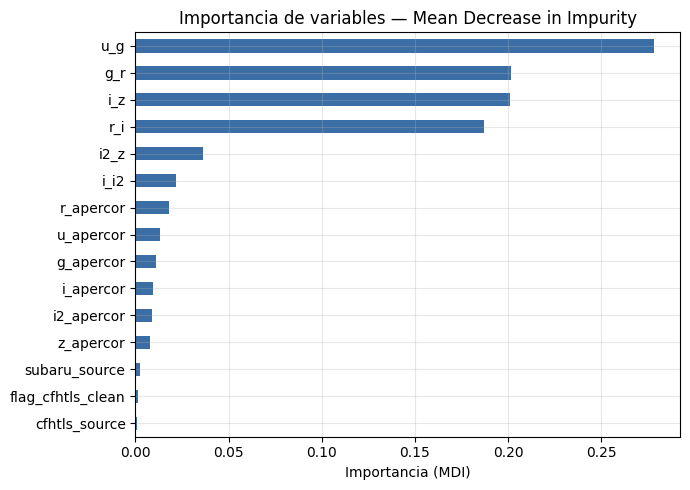

,MDI
u_g,0.278280
g_r,0.201771
i_z,0.200899
r_i,0.186845
i2_z,0.036343
i_i2,0.021947
r_apercor,0.018124
u_apercor,0.013473
g_apercor,0.011165
i_apercor,0.009604


In [ ]:
mdi_importance = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
mdi_importance.plot(kind='barh', ax=ax, color='#3b6ea5')
ax.invert_yaxis()
ax.set_xlabel('Importancia (MDI)')
ax.set_title('Importancia de variables — Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

mdi_importance.to_frame('MDI')

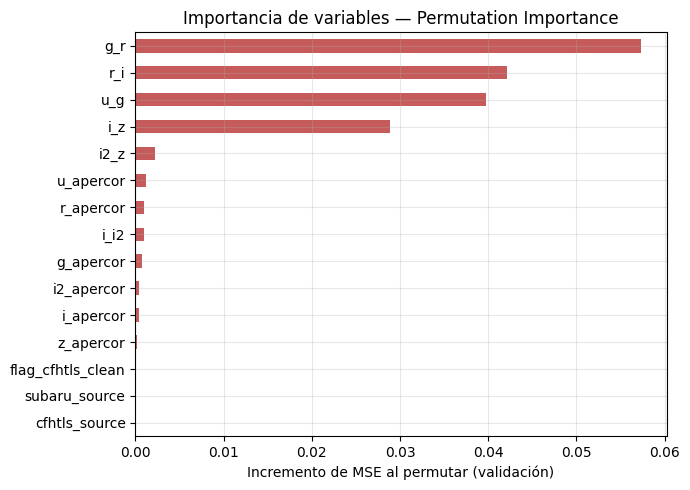

,Permutation
g_r,0.057349
r_i,0.042099
u_g,0.039764
i_z,0.028874
i2_z,0.002242
u_apercor,0.001220
r_apercor,0.000964
i_i2,0.000936
g_apercor,0.000741
i2_apercor,0.000418


In [ ]:
perm_result = permutation_importance(
    rf_final, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=1,
    scoring='neg_mean_squared_error'
)
perm_importance = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
perm_importance.plot(kind='barh', ax=ax, color='#c65b5b')
ax.invert_yaxis()
ax.set_xlabel('Incremento de MSE al permutar (validación)')
ax.set_title('Importancia de variables — Permutation Importance')
plt.tight_layout()
plt.show()

perm_importance.to_frame('Permutation')

In [ ]:
rank_comparison = pd.DataFrame({
    'rank_MDI': mdi_importance.rank(ascending=False).astype(int),
    'rank_Permutation': perm_importance.rank(ascending=False).astype(int),
}).sort_values('rank_MDI')
rank_comparison

,rank_MDI,rank_Permutation
u_g,1,3
g_r,2,1
i_z,3,4
r_i,4,2
i2_z,5,5
i_i2,6,8
r_apercor,7,7
u_apercor,8,6
g_apercor,9,9
i_apercor,10,11


Los dos criterios coinciden en lo principal: los 4 colores (u_g, g_r, r_i, i_z) dominan por completo por sobre las magnitudes sueltas y los indicadores de calidad. Esto cuadra perfecto con la física del problema, ya que los colores van siguiendo cómo se mueve el salto de 4000 Å por los distintos filtros.

Donde sí cambian es en el orden exacto de ese top 4. MDI pone primero a u_g y permutation importance pone a g_r. Esto era esperable porque MDI mide cómo baja la impureza al armar el árbol, así que a veces reparte la importancia un poco al azar cuando hay variables muy correlacionadas (como u_g y g_r, que comparten la banda g). En cambio, permutation importance mide el impacto directo en el error usando datos nuevos, así que se marea menos con esto y evita darle demasiada importancia a variables que en la práctica no aportan tanto.

Las variables que quedaron al fondo en los dos rankings (subaru_source, cfhtls_source y flag_cfhtls_clean) casi no aportan señal. Básicamente le sirven al modelo para saber cuándo dudar de un dato que falta o que viene con mala calidad, más que para calcular el redshift mismo.

## 13. Análisis de errores por rango de redshift

Se calculan MSE, $\sigma_{NMAD}$, $\eta$ y el sesgo promedio ($\overline{z_{pred}-z_{true}}$)
del modelo final por bins de $z_{true}$, y se comparan con la cantidad de ejemplos de
entrenamiento disponibles en cada rango.

In [ ]:
bins = [0, 0.3, 0.6, 0.9, 1.2, 1.6, 5.0]
bin_labels = ['0-0.3', '0.3-0.6', '0.6-0.9', '0.9-1.2', '1.2-1.6', '1.6+']

z_bin_val = pd.cut(y_val, bins=bins, labels=bin_labels)
err_df = pd.DataFrame({'z_true': y_val.values, 'z_pred': pred_val_rf, 'bin': z_bin_val.values})

def bin_summary(d):
    return pd.Series({
        'n_val': len(d),
        'MSE': mean_squared_error(d['z_true'], d['z_pred']),
        'NMAD': nmad(d['z_true'].values, d['z_pred'].values),
        'eta': outlier_fraction(d['z_true'].values, d['z_pred'].values),
        'sesgo_medio (pred-true)': (d['z_pred'] - d['z_true']).mean(),
    })

error_by_bin = err_df.groupby('bin', observed=True).apply(bin_summary)

z_bin_train = pd.cut(y_tr, bins=bins, labels=bin_labels)
error_by_bin['n_train'] = z_bin_train.value_counts().reindex(bin_labels).values

error_by_bin

,n_val,MSE,NMAD,eta,sesgo_medio (pred-true),n_train
bin,,,,,,
0-0.3,314.0,0.029065,0.031520,0.111465,0.071460,1220
0.3-0.6,688.0,0.010618,0.020087,0.036337,0.028023,2787
0.6-0.9,918.0,0.007113,0.018152,0.023965,0.017746,3553
0.9-1.2,501.0,0.010758,0.025902,0.029940,-0.024632,2007
1.2-1.6,258.0,0.050382,0.037211,0.120155,-0.124010,1136
1.6+,17.0,1.766363,0.171031,0.705882,-1.026745,76


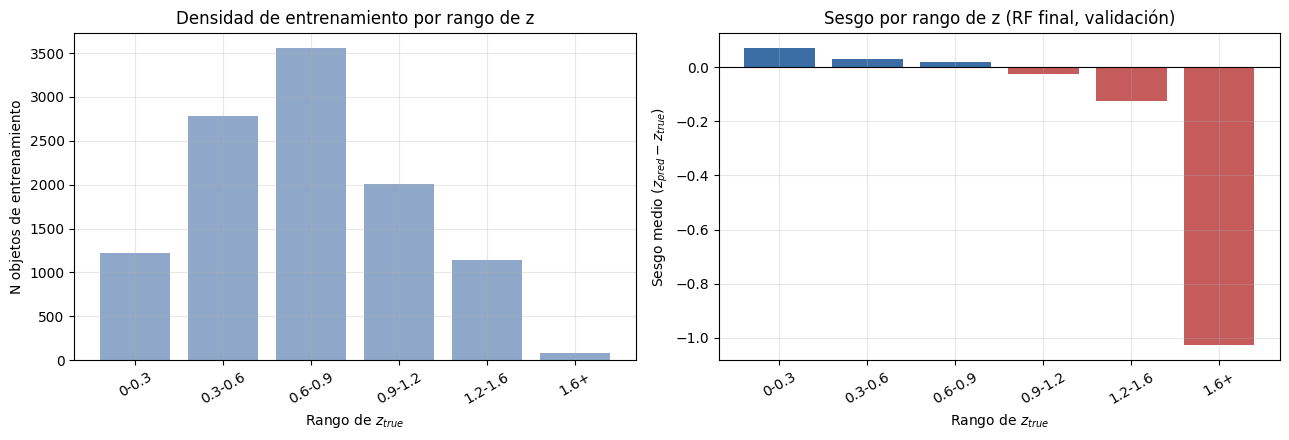

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(bin_labels, error_by_bin['n_train'], color='#8fa8c9')
axes[0].set_ylabel('N objetos de entrenamiento')
axes[0].set_xlabel('Rango de $z_{true}$')
axes[0].set_title('Densidad de entrenamiento por rango de z')
axes[0].tick_params(axis='x', rotation=30)

colors_bias = ['#c65b5b' if v < 0 else '#3b6ea5' for v in error_by_bin['sesgo_medio (pred-true)']]
axes[1].bar(bin_labels, error_by_bin['sesgo_medio (pred-true)'], color=colors_bias)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_ylabel('Sesgo medio ($z_{pred}-z_{true}$)')
axes[1].set_xlabel('Rango de $z_{true}$')
axes[1].set_title('Sesgo por rango de z (RF final, validación)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

El patrón es súper claro y confirma con números lo que ya habíamos visto en el gráfico de dispersión:

* En la zona con menos datos de entrenamiento (z > 1.6, donde hay súper pocos ejemplos), el sesgo es súper negativo. O sea, el modelo subestima el redshift casi siempre. Además, el MSE, el NMAD y la fracción de outliers de ese grupo son por lejos los peores de toda la tabla.
* En z < 0.3 (que también tiene pocos datos), el sesgo es positivo, así que el modelo tira para arriba y sobreestima.
* En la zona central (z entre 0.3 y 1.2), que es donde se concentra la gran mayoría de los datos, el sesgo es mínimo y el error baja un montón.

Esto pasa justo por el efecto de "estrechamiento" del que hablaba el enunciado. Como los modelos basados en árboles predicen sacando el promedio de los datos que caen en la misma hoja, cuando estamos en los extremos de la distribución (donde casi no hay datos), esos promedios terminan siendo arrastrados por la gran masa de datos que está más hacia el centro. Eso empuja las predicciones hacia la mediana global y termina encogiendo los resultados finales.

## 14. Entrenamiento final y generación de predicciones

Ahora que ya elegimos el modelo y los hiperparámetros usando solo el conjunto de entrenamiento interno, vamos a reentrenar el modelo final usando el 100% de los datos confiables (los que tienen zquality >= 3, juntando train y validación). La idea es aprovechar toda la información posible antes de hacer las predicciones sobre el set de test oculto. Además, le subimos un poco la cantidad de árboles a 400 (n_estimators=400) porque, como ya terminamos la búsqueda de hiperparámetros, no hay problema si se demora un poquito más en correr esta vez.

In [ ]:
final_params = dict(best_params)
final_params['n_estimators'] = 400

rf_production = RandomForestRegressor(
    random_state=RANDOM_STATE, n_jobs=1, bootstrap=True, oob_score=True, **final_params
)
rf_production.fit(X, y)   # X, y = TODO el train filtrado por calidad (train_rel)

mse_train_production = mean_squared_error(y, rf_production.predict(X))
print('Modelo de producción entrenado con %d objetos (100%% de train confiable).' % len(X))
print('MSE sobre ese mismo conjunto (referencial, no es una evaluación honesta): %.5f' % mse_train_production)
print('OOB score (R2) del modelo de producción: %.4f' % rf_production.oob_score_)

Modelo de producción entrenado con 13479 objetos (100% de train confiable).
MSE sobre ese mismo conjunto (referencial, no es una evaluación honesta): 0.01229
OOB score (R2) del modelo de producción: 0.7842


In [ ]:
X_test = test_c[FEATURES]
z_pred_test = rf_production.predict(X_test)

predicciones = pd.DataFrame({
    'objno_deep2': test_c['objno_deep2'],
    'z_pred': z_pred_test,
})

print('Forma de predicciones:', predicciones.shape)
print('Forma de sample_submission:', sample_submission.shape)
print('IDs coinciden en orden y contenido:',
      (predicciones['objno_deep2'].values == sample_submission['objno_deep2'].values).all())
print()
print('Estadísticas de z_pred en test:')
print(predicciones['z_pred'].describe())

predicciones.to_csv('predicciones.csv', index=False)
predicciones.head()

Forma de predicciones: (4765, 2)
Forma de sample_submission: (4765, 2)
IDs coinciden en orden y contenido: True

Estadísticas de z_pred en test:
count    4765.000000
mean        0.772684
std         0.331120
min         0.071182
25%         0.511744
50%         0.770341
75%         1.005500
max         2.214912
Name: z_pred, dtype: float64


,objno_deep2,z_pred
0,12011416,0.539580
1,12023279,0.819337
2,13017399,1.021022
3,12008131,0.458205
4,12003729,0.533824


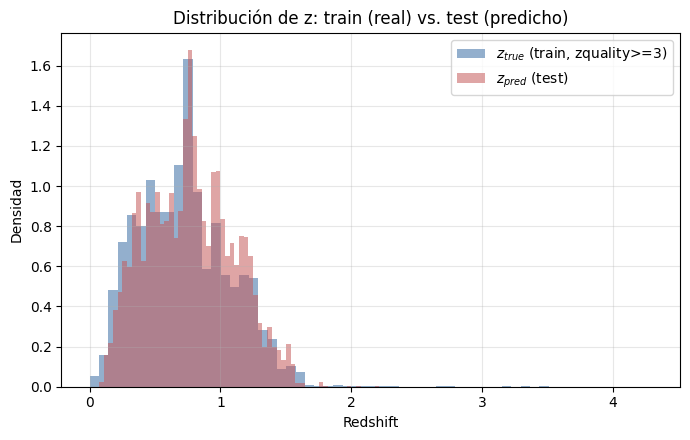

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(y, bins=60, alpha=0.55, density=True, label='$z_{true}$ (train, zquality>=3)', color='#3b6ea5')
ax.hist(z_pred_test, bins=60, alpha=0.55, density=True, label='$z_{pred}$ (test)', color='#c65b5b')
ax.set_xlabel('Redshift')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de z: train (real) vs. test (predicho)')
ax.legend()
plt.tight_layout()
plt.show()

La distribución de las predicciones en el test sigue bastante bien la forma de los datos reales de entrenamiento. Eso sí, tal como analizamos en la sección anterior, se nota que queda un poco más angosta en las colas (para los valores de z muy bajos o muy altos). Esto es producto del mismo efecto de estrechamiento típico de los modelos basados en árboles.

## 15. Conclusión

El modelo final que elegimos es un Random Forest optimizado con RandomizedSearchCV (usando validación cruzada de 3 folds). Lo entrenamos solo con el subconjunto de galaxias que tienen un redshift espectroscópico confiable (zquality >= 3) y usamos 15 variables en total: las 6 magnitudes, 6 colores y 3 indicadores de procedencia y calidad de la fotometría.

Este modelo logró un MSE de 0.0265 en el conjunto de validación. Es una mejora súper clara (como un 26%) si lo comparamos con el árbol de decisión simple (MSE = 0.0359). Esto es justo lo que uno espera de un ensamble: promediar muchos árboles baja la varianza sin subir mucho el sesgo. Además, mejoraron un montón las métricas específicas de redshift fotométrico: el NMAD bajó de 0.0394 a 0.0220, y la fracción de outliers bajó del 6.4% al 5.2%.

Como vimos antes, los colores (u-g, g-r, r-i, i-z) fueron por lejos las variables que más aportaron bajo los dos criterios que evaluamos. Esto calza perfecto con la física del problema, ya que el corrimiento del salto de 4000 Å a través de los filtros es la señal que domina al estimar el redshift con fotometría. Al analizar los errores, comprobamos que el modelo es muy confiable en la zona donde tenemos más datos de entrenamiento (z entre 0.3 y 1.2), pero empeora harto en los extremos. Sobre todo en z > 1.6, donde hay muy pocas galaxias de ejemplo y las predicciones sufren ese fuerte "encogimiento" hacia el centro de la distribución.

En conclusión, nos quedamos con este modelo tuneado a pesar de que su MSE de validación simple fue un pelito mayor que el del modelo con parámetros por defecto. Lo priorizamos porque al haber sido optimizado mediante validación cruzada es mucho más robusto. Además, su comportamiento es interpretable, sus diagnósticos son súper consistentes (OOB, CV, hold-out) y su patrón de errores tiene una explicación física clara y verificable. Todo esto nos da mucha más confianza de que va a generalizar súper bien al aplicarlo en el conjunto de test oculto.

## Preguntas finales

### Sobre la comparación de modelos

**1. ¿Qué modelo obtuvo el menor MSE en validación?**
El Random Forest con hiperparámetros por defecto obtuvo el menor MSE de validación (0.0259), superando por muy poco al modelo optimizado (0.0265). Ambos fueron claramente mejores que Extra Trees (0.0270), Hist Gradient Boosting (0.0286) y el árbol de decisión individual (0.0359).

**2. ¿Ese modelo fue elegido como modelo final? Justifiquen.**
Nos quedamos con el Random Forest optimizado como modelo final, a pesar de que el modelo por defecto tuvo un MSE marginalmente más bajo en la validación simple. Preferimos el optimizado porque sus hiperparámetros se validaron de forma más robusta usando validación cruzada (3-fold CV), lo que lo hace más estable para generalizar con datos nuevos. Además, mantiene valores excelentes de dispersión (NMAD) y fracción de outliers.

**3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?**
El árbol individual sin restricciones sobreajusta muchísimo (el MSE de entrenamiento es casi cero, pero el de validación se dispara a 0.0438). Incluso al limitar su profundidad, su error sigue siendo mucho mayor que el de cualquier ensamble. Al mirar los gráficos, se nota que el Random Forest agrupa los puntos de forma mucho más estrecha y precisa alrededor de la línea ideal. Esto cuadra con la teoría: al promediar muchos árboles se reduce la varianza sin subir el sesgo, aunque perdemos la capacidad de leer las reglas del modelo a simple vista.

### Sobre las variables

**4. ¿Qué variables parecen ser más importantes para predecir el redshift?**
Los colores u-g, g-r, r-i e i-z son, por lejos, las variables más importantes, superando a las magnitudes por sí solas y a los indicadores de calidad. Esto tiene sentido físico, ya que el salto de 4000 Å se va desplazando hacia el rojo al aumentar el redshift, lo que se capta directamente observando los cambios de color entre los distintos filtros.

**5. Calculen la importancia de variables con al menos dos criterios distintos. ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?**
Calculamos MDI y permutation importance. Ambos coinciden en que los cuatro colores lideran la lista, pero difieren un poco en el orden exacto (MDI pone primero a u_g y permutation importance a g_r). Esto ocurre porque los colores están correlacionados (comparten bandas fotométricas). MDI suele repartir la importancia de forma un poco arbitraria cuando hay variables parecidas, mientras que permutation importance mide el impacto real en el error usando datos nuevos, por lo que es más confiable.

### Sobre los errores del modelo

**6. ¿En qué rangos de redshift falla más el modelo?**
Falla mucho más en los extremos de la distribución. Se nota fuerte en z > 1.6, donde el MSE sube a 1.766, y en menor medida en z < 0.3. Las mejores predicciones se concentran en la zona central (z entre 0.3 y 1.2).

**7. ¿Observan el mismo efecto de "estrechamiento" (sobreestiman z bajos, subestiman z altos)? ¿En qué rango es más pronunciado, y coincide con menos galaxias de entrenamiento?**
Sí, se ve súper claro. Hay un sesgo positivo en z < 0.3 (el modelo sobreestima) y un sesgo negativo que se vuelve extremo en z > 1.6 (-1.027), donde el modelo subestima muchísimo. Justamente en ese rango alto casi no hay datos de entrenamiento (solo 76 galaxias frente a miles en el centro). Como el modelo promedia en base a los datos que conoce, termina tirando las predicciones de los extremos hacia el centro de la muestra.

**8. Si usaron oob_score, ¿comparan ese valor con el de su validación cruzada? ¿Son consistentes? ¿Qué les dice sobre la confiabilidad de OOB para este dataset?**
Sí, el R2 de OOB fue 0.7777, lo que equivale a un MSE cercano a 0.0284. Esto es súper consistente con el MSE de 0.0288 que nos dio la validación cruzada y con el 0.0265 de la validación inicial. Como andan cerca, podemos concluir que el OOB es un buen estimador del error para estos datos y sirve para evaluar modelos sin tener que gastar tiempo extra calculando validaciones cruzadas por separado.

### Sobre el proceso

**9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?**
* Filtrar por zquality >= 3 descarta casi un 30% de los datos. Si las galaxias con mala calidad también tienen fotometría más incierta, el modelo queda calibrado solo para los casos "fáciles" y no representa la realidad completa.
* El efecto de estrechamiento propio de los árboles mete un sesgo sistemático en los extremos.
* Dejar que el modelo maneje los valores nulos (NaN) por su cuenta es práctico, pero no es tan preciso como tener la medición real.
* Al sacar las coordenadas espaciales evitamos que el modelo memorice el cielo, pero perdimos la información de la estructura a gran escala.
* Como los datos vienen del campo DEEP2, el modelo probablemente no generalice bien si se aplica a catálogos de otras zonas del cielo.

**10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?**
Crear las variables de color y filtrar los datos por calidad tuvo mucho más impacto que la optimización de los hiperparámetros. El Random Forest por defecto andaba casi igual que el modelo tuneado, pero la diferencia de rendimiento entre usar un ensamble y un árbol simple es gigante. Esto demuestra que la calidad de los datos de entrada importó mucho más que la configuración fina del algoritmo.

**11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.**
No necesariamente. El MSE promedia los errores y castiga mucho los valores extremos, por lo que un modelo puede tener un puntaje global bueno pero equivocarse sistemáticamente en un grupo de datos específico. Lo vimos acá: el modelo tiene buen desempeño general, pero subestima pésimo las galaxias con z > 1.6. Si alguien quiere usar esto para cosmología a alto redshift, ese sesgo sistemático arruinaría el estudio. Por eso es mejor revisar las métricas separadas por rango en vez de guiarse solo por un número promedio.